# 11 — Frozen cleaning schema and whole-recording sequence-model pilot

This notebook creates a versioned, auditable processed table from the 11 reviewed long recordings **without editing any raw file**.

It then performs a deliberately small pilot:

- primary evaluation: train on 10 complete recordings and test on the untouched August parallel-strip recording;
- robustness audit: repeat the same fixed model specification while leaving each complete recording out once;
- comparison: current 32-channel response versus causal temporal features.

The target is the **protocol-approximate source region** at the lag-corrected snout position: background, mint, or lavender. It is not direct chemical ground truth. Eleven recordings are eleven independent groups—not thousands of independent experiments.


In [1]:
from __future__ import annotations

import sys
import site
from pathlib import Path
USER_SITE = Path(site.getusersitepackages()).resolve()
sys.path[:] = [entry for entry in sys.path if not entry or Path(entry).resolve() != USER_SITE]

import hashlib
import json
import math
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, recall_score

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists(), f"Repository root not found from {Path.cwd()}"

OUTPUT_DIR = ROOT / "experiments" / "long-sequence" / "processed" / "cleaning-v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCHEMA_VERSION = "long-sequence-cleaning-v1"
MODEL_VERSION = "source-region-temporal-pilot-v1"
PRIMARY_HOLDOUT = "20260803_170357"
PAPER_SIZE_CM = 26.5
PAPER_X_ORIGIN = 40.0
PAPER_Y_ORIGIN = 46.5
PHYSICAL_LAG_S = 2.0
MAX_LAG_POSE_GAP_S = 1.5
HEIGHT_MIN_CM = 1.0
HEIGHT_MAX_CM = 3.5
MIN_TEMPORAL_HISTORY_S = 6.0
EVALUATION_THINNING_S = 1.5
REGULARIZATION_C = 0.01
RANDOM_SEED = 20260803
CLASS_ORDER = ["background", "mint", "lavender"]
SENSOR_SOURCE_COLUMNS = [f"pcnose_S{i}_kohm" for i in range(1, 33)]
RAW_COLUMNS = [f"raw_S{i}_kohm" for i in range(1, 33)]
NORMALIZED_COLUMNS = [f"baseline_normalized_S{i}_pct" for i in range(1, 33)]
MODEL_COLUMNS = [f"model_response_S{i}_pct" for i in range(1, 33)]

SEGMENTS = {
    "horizontal": ((4.75, 13.25), (21.75, 13.25), 3.0),
    "caret_left": ((4.75, 21.5), (11.25, 5.0), 3.0),
    "caret_right": ((15.25, 5.0), (21.75, 21.5), 3.0),
    "inverted_left": ((4.75, 5.0), (11.25, 21.5), 3.0),
    "inverted_right": ((15.25, 21.5), (21.75, 5.0), 3.0),
    "x_backslash": ((3.5, 3.5), (23.0, 23.0), 2.0),
    "x_slash": ((3.5, 23.0), (23.0, 3.5), 2.0),
    "aug_inverted_left": ((3.5, 3.5), (11.25, 23.0), 2.0),
    "aug_inverted_right": ((23.0, 3.5), (15.25, 23.0), 2.0),
    "parallel_top": ((4.75, 7.0), (21.75, 7.0), 2.0),
    "parallel_bottom": ((4.75, 19.75), (21.75, 19.75), 2.0),
}

JULY = ROOT / "experiments" / "long-sequence" / "2026-07-30_batch-01" / "runs"
AUGUST = ROOT / "experiments" / "long-sequence" / "2026-08-03_batch-01" / "runs"
RUN_SPECS = [
    dict(session="20260730_152754", path=JULY, layout="mint horizontal", mint=["horizontal"], lavender=[]),
    dict(session="20260730_153631", path=JULY, layout="caret mint-left lavender-right", mint=["caret_left"], lavender=["caret_right"]),
    dict(session="20260730_154848", path=JULY, layout="caret lavender-left mint-right", mint=["caret_right"], lavender=["caret_left"]),
    dict(session="20260730_161358", path=JULY, layout="lavender horizontal", mint=[], lavender=["horizontal"]),
    dict(session="20260730_163355", path=JULY, layout="inverted caret lavender-left mint-right", mint=["inverted_right"], lavender=["inverted_left"]),
    dict(session="20260803_144217", path=AUGUST, layout="X mint-backslash lavender-slash 01", mint=["x_backslash"], lavender=["x_slash"]),
    dict(session="20260803_150952", path=AUGUST, layout="X mint-backslash lavender-slash 02", mint=["x_backslash"], lavender=["x_slash"]),
    dict(session="20260803_154420", path=AUGUST, layout="X lavender-backslash mint-slash 03", mint=["x_slash"], lavender=["x_backslash"]),
    dict(session="20260803_160842", path=AUGUST, layout="X lavender-backslash mint-slash 04", mint=["x_slash"], lavender=["x_backslash"]),
    dict(session="20260803_164023", path=AUGUST, layout="inverted caret lavender-left mint-right", mint=["aug_inverted_right"], lavender=["aug_inverted_left"]),
    dict(session="20260803_170357", path=AUGUST, layout="parallel mint-top lavender-bottom", mint=["parallel_top"], lavender=["parallel_bottom"]),
]
for spec in RUN_SPECS:
    spec["session_id"] = "cyranose_reading_pose_session_" + spec["session"]
    spec["run_dir"] = spec["path"] / spec["session_id"]
    spec["csv"] = spec["run_dir"] / "cyranose_reading_pose.csv"
    spec["metadata"] = spec["run_dir"] / "session_metadata.json"
    assert spec["csv"].exists(), spec["csv"]

print("Output directory:", OUTPUT_DIR)
print("Primary untouched holdout:", PRIMARY_HOLDOUT)
print("Independent recordings:", len(RUN_SPECS))


Output directory: C:\Users\dell-xps\Documents\realsense-apriltag\experiments\long-sequence\processed\cleaning-v1
Primary untouched holdout: 20260803_170357
Independent recordings: 11


In [2]:
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def bool_series(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def point_segment_distance(x: np.ndarray, y: np.ndarray, segment) -> np.ndarray:
    (x1, y1), (x2, y2), _ = segment
    vx, vy = x2 - x1, y2 - y1
    t = np.clip(((x - x1) * vx + (y - y1) * vy) / (vx * vx + vy * vy), 0.0, 1.0)
    return np.hypot(x - (x1 + t * vx), y - (y1 + t * vy))


def source_labels(x: np.ndarray, y: np.ndarray, spec: dict, margin_cm: float = 1.0) -> np.ndarray:
    mint = np.zeros(len(x), dtype=bool)
    lavender = np.zeros(len(x), dtype=bool)
    for name in spec["mint"]:
        segment = SEGMENTS[name]
        mint |= point_segment_distance(x, y, segment) <= segment[2] / 2.0 + margin_cm
    for name in spec["lavender"]:
        segment = SEGMENTS[name]
        lavender |= point_segment_distance(x, y, segment) <= segment[2] / 2.0 + margin_cm
    label = np.full(len(x), "background", dtype=object)
    label[mint] = "mint"
    label[lavender] = "lavender"
    label[mint & lavender] = "overlap"
    label[~np.isfinite(x) | ~np.isfinite(y)] = "unknown"
    return label


def isolated_spike_rows(resistance: np.ndarray, flag: np.ndarray, deviation_pct: float = 10.0, neighbor_pct: float = 3.0) -> np.ndarray:
    if len(resistance) < 3:
        return np.array([], dtype=int)
    midpoint = (resistance[:-2] + resistance[2:]) / 2.0
    scale = np.maximum(np.abs(midpoint), 1e-9)
    center_deviation = 100.0 * np.abs(resistance[1:-1] - midpoint) / scale
    neighbor_disagreement = 100.0 * np.abs(resistance[2:] - resistance[:-2]) / scale
    bad = (center_deviation > deviation_pct) & (neighbor_disagreement < neighbor_pct)
    rows = np.flatnonzero(np.any(bad, axis=1)) + 1
    return rows[flag[rows] == 2]


def irregular_ema(times: np.ndarray, values: np.ndarray, tau_s: float) -> np.ndarray:
    result = np.empty_like(values, dtype=float)
    result[0] = values[0]
    for index in range(1, len(values)):
        dt = max(float(times[index] - times[index - 1]), 0.0)
        alpha = math.exp(-dt / tau_s)
        result[index] = alpha * result[index - 1] + (1.0 - alpha) * values[index]
    return result


def interpolate_vectors(times: np.ndarray, values: np.ndarray, query_times: np.ndarray) -> np.ndarray:
    return np.column_stack([
        np.interp(query_times, times, values[:, sensor_index])
        for sensor_index in range(values.shape[1])
    ])


def collect_reasons(flag, sensor_complete, history_pass, spike_flag, sync_valid, lag_pose_valid, inside_paper, height_pass, label):
    reasons = []
    for index in range(len(flag)):
        current = []
        if flag[index] != 2:
            current.append("not_flag2_measurement")
        if not sensor_complete[index]:
            current.append("incomplete_sensor_vector")
        if not history_pass[index]:
            current.append("insufficient_6s_history")
        if spike_flag[index]:
            current.append("isolated_sensor_spike")
        if not sync_valid[index]:
            current.append("stored_pose_alignment_invalid")
        if not lag_pose_valid[index]:
            current.append("lag_corrected_pose_unavailable")
        elif not inside_paper[index]:
            current.append("outside_registered_paper")
        elif not height_pass[index]:
            current.append("height_outside_1_0_to_3_5_cm")
        if label[index] == "overlap":
            current.append("approximate_source_overlap")
        elif label[index] == "unknown":
            current.append("source_label_unavailable")
        reasons.append(";".join(current))
    return reasons


def process_run(spec: dict):
    frame = pd.read_csv(spec["csv"])
    raw_hash = sha256(spec["csv"])
    metadata = json.loads(spec["metadata"].read_text(encoding="utf-8")) if spec["metadata"].exists() else {}
    resistance = frame[SENSOR_SOURCE_COLUMNS].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    flag = pd.to_numeric(frame["pcnose_flag"], errors="coerce").fillna(-1).to_numpy(int)
    host_time = pd.to_datetime(frame["pcnose_sample_time_estimate_utc"], errors="coerce", utc=True)
    assert host_time.notna().all()
    host_elapsed = (host_time - host_time.iloc[0]).dt.total_seconds().to_numpy(float)

    flag1 = resistance[flag == 1]
    assert len(flag1) >= 4
    baseline = np.nanmedian(flag1[len(flag1) // 2 :], axis=0)
    normalized = 100.0 * (resistance - baseline) / np.maximum(np.abs(baseline), 1e-12)
    model_response = pd.DataFrame(normalized).rolling(3, min_periods=1).median().to_numpy(float)

    spikes = isolated_spike_rows(resistance, flag)
    spike_flag = np.zeros(len(frame), dtype=bool)
    spike_flag[spikes] = True
    sensor_complete = np.isfinite(resistance).all(axis=1)
    history_pass = host_elapsed >= MIN_TEMPORAL_HISTORY_S
    sync_valid = bool_series(frame["pose_alignment_valid"]).to_numpy()
    sync_pose_gap_ms = pd.to_numeric(frame["abs_pose_minus_pcnose_ms"], errors="coerce").to_numpy(float)

    snout_valid = bool_series(frame["snout_position_valid"]).to_numpy()
    pose_elapsed = pd.to_numeric(frame["pose_elapsed_s"], errors="coerce").to_numpy(float)
    pose_x = pd.to_numeric(frame["snout_desk_x_cm"], errors="coerce").to_numpy(float)
    pose_y = pd.to_numeric(frame["snout_desk_y_cm"], errors="coerce").to_numpy(float)
    pose_height = -pd.to_numeric(frame["snout_desk_z_cm"], errors="coerce").to_numpy(float)
    valid_pose_rows = snout_valid & np.isfinite(pose_elapsed) & np.isfinite(pose_x) & np.isfinite(pose_y) & np.isfinite(pose_height)
    valid_indices = np.flatnonzero(valid_pose_rows)

    lag_gap = np.full(len(frame), np.nan)
    paper_x = np.full(len(frame), np.nan)
    paper_y = np.full(len(frame), np.nan)
    height = np.full(len(frame), np.nan)
    if len(valid_indices):
        valid_t = pose_elapsed[valid_indices]
        for row_index in range(len(frame)):
            if not np.isfinite(pose_elapsed[row_index]):
                continue
            target = pose_elapsed[row_index] - PHYSICAL_LAG_S
            nearest_local = int(np.argmin(np.abs(valid_t - target)))
            nearest = int(valid_indices[nearest_local])
            gap = abs(float(valid_t[nearest_local] - target))
            lag_gap[row_index] = gap
            if gap <= MAX_LAG_POSE_GAP_S:
                paper_x[row_index] = PAPER_X_ORIGIN - pose_x[nearest]
                paper_y[row_index] = PAPER_Y_ORIGIN - pose_y[nearest]
                height[row_index] = pose_height[nearest]

    lag_pose_valid = np.isfinite(paper_x) & (lag_gap <= MAX_LAG_POSE_GAP_S)
    inside_paper = lag_pose_valid & (paper_x >= 0) & (paper_x <= PAPER_SIZE_CM) & (paper_y >= 0) & (paper_y <= PAPER_SIZE_CM)
    height_pass = inside_paper & (height >= HEIGHT_MIN_CM) & (height <= HEIGHT_MAX_CM)
    label = source_labels(paper_x, paper_y, spec, margin_cm=1.0)
    label[lag_pose_valid & ~inside_paper] = "outside_paper"

    reasons = collect_reasons(
        flag, sensor_complete, history_pass, spike_flag, sync_valid,
        lag_pose_valid, inside_paper, height_pass, label
    )
    sequence_eligible = (
        (flag == 2) & sensor_complete & history_pass & ~spike_flag & sync_valid
        & lag_pose_valid & inside_paper & height_pass
        & np.isin(label, ["background", "mint", "lavender"])
    )
    spatial_eligible = sync_valid & lag_pose_valid & inside_paper & height_pass

    processed = pd.DataFrame({
        "cleaning_schema_version": SCHEMA_VERSION,
        "session_id": spec["session"],
        "trial_id": metadata.get("trial_id", ""),
        "layout": spec["layout"],
        "raw_csv_relative_path": spec["csv"].relative_to(ROOT).as_posix(),
        "raw_csv_sha256": raw_hash,
        "raw_row_index": np.arange(len(frame), dtype=int),
        "host_time_utc": host_time.dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ"),
        "host_elapsed_s": host_elapsed,
        "pcnose_flag": flag,
        "sensor_vector_complete": sensor_complete,
        "isolated_spike_flag": spike_flag,
        "stored_pose_alignment_valid": sync_valid,
        "synchronized_pose_gap_ms": sync_pose_gap_ms,
        "lag_correction_s": PHYSICAL_LAG_S,
        "lag_corrected_pose_gap_s": lag_gap,
        "paper_x_cm": paper_x,
        "paper_y_cm": paper_y,
        "snout_height_cm": height,
        "inside_registered_paper": inside_paper,
        "height_pass_1_0_to_3_5_cm": height_pass,
        "temporal_history_6s_pass": history_pass,
        "approximate_source_label": label,
        "spatial_analysis_eligible": spatial_eligible,
        "sequence_model_eligible": sequence_eligible,
        "exclusion_reason": reasons,
        "processing_note": np.where(spike_flag, "raw spike retained; filtered model channel excluded from training at this row", ""),
    })
    processed[RAW_COLUMNS] = resistance
    processed[NORMALIZED_COLUMNS] = normalized
    processed[MODEL_COLUMNS] = model_response

    counts = processed["approximate_source_label"].value_counts()
    manifest_row = {
        "session_id": spec["session"],
        "trial_id": metadata.get("trial_id", ""),
        "layout": spec["layout"],
        "primary_role": "holdout" if spec["session"] == PRIMARY_HOLDOUT else "train",
        "raw_csv_relative_path": spec["csv"].relative_to(ROOT).as_posix(),
        "raw_csv_sha256": raw_hash,
        "raw_rows": len(frame),
        "sequence_model_eligible_rows": int(sequence_eligible.sum()),
        "background_rows": int(counts.get("background", 0)),
        "mint_rows": int(counts.get("mint", 0)),
        "lavender_rows": int(counts.get("lavender", 0)),
        "overlap_rows": int(counts.get("overlap", 0)),
        "unknown_or_outside_rows": int(counts.get("unknown", 0) + counts.get("outside_paper", 0)),
        "isolated_spike_rows": int(spike_flag.sum()),
    }
    for sensor_index, value in enumerate(baseline, start=1):
        manifest_row[f"baseline_S{sensor_index}_kohm"] = value
    return processed, manifest_row


In [3]:
schema = {
    "schema_version": SCHEMA_VERSION,
    "status": "frozen pilot preprocessing contract",
    "created_by": "Notebook 11",
    "raw_data_policy": "Raw CSV and MP4 files are read-only and never rewritten.",
    "time_basis": "pcnose_sample_time_estimate_utc, derived from the host serial-request midpoint",
    "paper_registration": {
        "paper_size_cm": [PAPER_SIZE_CM, PAPER_SIZE_CM],
        "paper_x_cm": f"{PAPER_X_ORIGIN} - snout_desk_x_cm",
        "paper_y_cm": f"{PAPER_Y_ORIGIN} - snout_desk_y_cm",
    },
    "rules": {
        "baseline": "Per run: median of the latter half of flag-1 rows, independently for each sensor.",
        "normalized_response": "100 * (raw resistance - baseline) / abs(baseline).",
        "model_response": "Trailing causal 3-row median of each normalized channel.",
        "isolated_spike": "Current row differs >10% from agreeing adjacent rows whose mutual difference is <3%; flag-2 rows only.",
        "physical_response_lag_s": PHYSICAL_LAG_S,
        "maximum_lag_corrected_pose_gap_s": MAX_LAG_POSE_GAP_S,
        "height_band_cm": [HEIGHT_MIN_CM, HEIGHT_MAX_CM],
        "minimum_temporal_history_s": MIN_TEMPORAL_HISTORY_S,
        "source_mask_margin_cm": 1.0,
        "source_overlap_policy": "Label overlap and exclude from sequence-model training/evaluation.",
        "spike_policy": "Preserve the raw row and filtered channels, flag it, and exclude that timestamp from model training/evaluation.",
        "evaluation_thinning_s": EVALUATION_THINNING_S,
    },
    "eligibility": {
        "spatial_analysis_eligible": "Stored alignment valid; lag-corrected pose available; inside paper; height within 1.0-3.5 cm.",
        "sequence_model_eligible": "Flag 2; complete sensors; >=6 s history; no isolated spike; valid stored and lag-corrected pose; inside paper; height pass; non-overlap background/mint/lavender label.",
    },
    "source_geometry": {
        name: {"start_xy_cm": list(segment[0]), "end_xy_cm": list(segment[1]), "width_cm": segment[2]}
        for name, segment in SEGMENTS.items()
    },
    "run_source_assignments": {
        spec["session"]: {"layout": spec["layout"], "mint_segments": spec["mint"], "lavender_segments": spec["lavender"]}
        for spec in RUN_SPECS
    },
    "field_groups": {
        "provenance": ["session_id", "raw_csv_relative_path", "raw_csv_sha256", "raw_row_index"],
        "time": ["host_time_utc", "host_elapsed_s", "pcnose_flag"],
        "raw_resistance_kohm": RAW_COLUMNS,
        "baseline_normalized_percent": NORMALIZED_COLUMNS,
        "causal_model_response_percent": MODEL_COLUMNS,
        "quality_and_pose": [
            "isolated_spike_flag", "synchronized_pose_gap_ms", "lag_corrected_pose_gap_s",
            "paper_x_cm", "paper_y_cm", "snout_height_cm", "height_pass_1_0_to_3_5_cm",
            "approximate_source_label", "sequence_model_eligible", "exclusion_reason"
        ],
    },
    "model_pilot": {
        "primary_holdout_session": PRIMARY_HOLDOUT,
        "training_sessions": [spec["session"] for spec in RUN_SPECS if spec["session"] != PRIMARY_HOLDOUT],
        "features": [
            "32 current causal-median response channels",
            "32 differences from 1.5 seconds earlier",
            "32 differences from 6.0 seconds earlier",
            "32 deviations from the causal 4.0-second EMA",
        ],
        "classifier": "StandardScaler + L2-regularized multinomial logistic regression",
        "regularization_C": REGULARIZATION_C,
        "class_weight": "balanced",
        "random_seed": RANDOM_SEED,
        "important_limitation": "Targets are approximate source regions, not direct chemical labels.",
    },
}

schema_path = OUTPUT_DIR / "cleaning_schema_v1.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
schema_sha256 = sha256(schema_path)

processed_parts = []
manifest_rows = []
for spec in RUN_SPECS:
    processed_part, manifest_row = process_run(spec)
    processed_parts.append(processed_part)
    manifest_rows.append(manifest_row)
processed = pd.concat(processed_parts, ignore_index=True)
manifest = pd.DataFrame(manifest_rows)
manifest.insert(0, "cleaning_schema_version", SCHEMA_VERSION)
manifest.insert(1, "cleaning_schema_sha256", schema_sha256)

table_path = OUTPUT_DIR / "long_sequence_processed_v1.csv.gz"
manifest_path = OUTPUT_DIR / "run_manifest.csv"
processed.to_csv(
    table_path, index=False, float_format="%.9g",
    compression={"method": "gzip", "compresslevel": 6, "mtime": 0}
)
manifest.to_csv(manifest_path, index=False, float_format="%.9g")

# Compact validation: row conservation, unique lineage, required field counts, raw spot checks.
assert len(processed) == sum(row["raw_rows"] for row in manifest_rows)
assert not processed.duplicated(["session_id", "raw_row_index"]).any()
blank_reason = processed["exclusion_reason"].eq("")
assert not (processed["sequence_model_eligible"] & ~blank_reason).any()
assert not (~processed["sequence_model_eligible"] & blank_reason).any()
assert all(group["host_elapsed_s"].is_monotonic_increasing for _, group in processed.groupby("session_id"))
assert all(
    group["raw_row_index"].tolist() == list(range(len(group)))
    for _, group in processed.groupby("session_id")
)
assert len([column for column in processed if column.startswith("raw_S")]) == 32
assert len([column for column in processed if column.startswith("baseline_normalized_S")]) == 32
assert len([column for column in processed if column.startswith("model_response_S")]) == 32
for spec in RUN_SPECS:
    raw = pd.read_csv(spec["csv"])
    exported = processed[processed["session_id"] == spec["session"]]
    for row_index in [0, len(raw) - 1]:
        np.testing.assert_allclose(
            raw.loc[row_index, SENSOR_SOURCE_COLUMNS].to_numpy(float),
            exported.loc[exported["raw_row_index"] == row_index, RAW_COLUMNS].iloc[0].to_numpy(float),
            rtol=0, atol=0
        )

validation = pd.DataFrame({
    "check": [
        "raw rows conserved", "unique session + raw-row key", "raw resistance columns",
        "normalized columns", "causal model columns", "eligibility reasons complete",
        "host time monotonic per run", "raw row index contiguous", "raw first/last spot checks"
    ],
    "result": ["PASS", "PASS", "32", "32", "32", "PASS", "PASS", "PASS", "PASS"],
})
display(validation)
display(manifest[[
    "session_id", "primary_role", "raw_rows", "sequence_model_eligible_rows",
    "background_rows", "mint_rows", "lavender_rows", "overlap_rows",
    "isolated_spike_rows"
]])

display(Markdown(
    f"""### Frozen export

- Schema: {schema_path.relative_to(ROOT)}
- Processed table: {table_path.relative_to(ROOT)}
- Run manifest: {manifest_path.relative_to(ROOT)}
- Rows preserved: **{len(processed):,}**
- Sequence-model-eligible rows before conservative time thinning: **{int(processed["sequence_model_eligible"].sum()):,}**
- Cleaning-schema SHA-256: **{schema_sha256}**

An exclusion reason is a statement about eligibility for this model—not a deletion. Every raw row remains present in the processed table.
"""
))


,check,result
0,raw rows conserved,PASS
1,unique session + raw-row key,PASS
2,raw resistance columns,32
3,normalized columns,32
4,causal model columns,32
5,eligibility reasons complete,PASS
6,host time monotonic per run,PASS
7,raw row index contiguous,PASS
8,raw first/last spot checks,PASS


,session_id,primary_role,raw_rows,sequence_model_eligible_rows,background_rows,mint_rows,lavender_rows,overlap_rows,isolated_spike_rows
0,20260730_152754,train,706,547,460,102,0,0,0
1,20260730_153631,train,737,578,450,138,92,5,0
2,20260730_154848,train,759,541,424,73,188,0,0
3,20260730_161358,train,829,681,614,0,130,0,0
4,20260730_163355,train,1114,883,620,171,170,3,0
5,20260803_144217,train,1118,524,647,145,186,22,0
6,20260803_150952,train,1134,810,725,149,166,33,0
7,20260803_154420,train,1181,889,721,181,156,48,1
8,20260803_160842,train,1163,832,735,163,163,34,0
9,20260803_164023,train,1205,1034,858,130,160,0,0


### Frozen export

- Schema: experiments\long-sequence\processed\cleaning-v1\cleaning_schema_v1.json
- Processed table: experiments\long-sequence\processed\cleaning-v1\long_sequence_processed_v1.csv.gz
- Run manifest: experiments\long-sequence\processed\cleaning-v1\run_manifest.csv
- Rows preserved: **11,082**
- Sequence-model-eligible rows before conservative time thinning: **8,219**
- Cleaning-schema SHA-256: **3fc5195d5643344031426aef323c622b51f0460cc11ca49a2d06d1ad5f8bf808**

An exclusion reason is a statement about eligibility for this model—not a deletion. Every raw row remains present in the processed table.


In [4]:
def build_feature_rows(processed_table: pd.DataFrame) -> pd.DataFrame:
    feature_rows = []
    for session, group in processed_table.groupby("session_id", sort=False):
        group = group.sort_values("raw_row_index").reset_index(drop=True)
        times = group["host_elapsed_s"].to_numpy(float)
        values = group[MODEL_COLUMNS].to_numpy(float)
        eligible_positions = np.flatnonzero(group["sequence_model_eligible"].to_numpy(bool))
        current = values[eligible_positions]
        delta_15 = current - interpolate_vectors(times, values, times[eligible_positions] - 1.5)
        delta_60 = current - interpolate_vectors(times, values, times[eligible_positions] - 6.0)
        ema_40 = irregular_ema(times, values, 4.0)
        ema_deviation = current - ema_40[eligible_positions]
        for local_index, position in enumerate(eligible_positions):
            feature_rows.append({
                "session_id": session,
                "raw_row_index": int(group.loc[position, "raw_row_index"]),
                "host_time_utc": group.loc[position, "host_time_utc"],
                "host_elapsed_s": float(times[position]),
                "target_source_label": group.loc[position, "approximate_source_label"],
                "paper_x_cm": float(group.loc[position, "paper_x_cm"]),
                "paper_y_cm": float(group.loc[position, "paper_y_cm"]),
                "snout_height_cm": float(group.loc[position, "snout_height_cm"]),
                "features_current": current[local_index],
                "features_temporal": np.concatenate([
                    current[local_index], delta_15[local_index],
                    delta_60[local_index], ema_deviation[local_index]
                ]),
            })
    return pd.DataFrame(feature_rows)


def conservatively_thin(feature_rows: pd.DataFrame, minimum_gap_s: float) -> pd.DataFrame:
    keep = []
    for _, group in feature_rows.sort_values(["session_id", "host_elapsed_s"]).groupby("session_id", sort=False):
        last_time = -np.inf
        for index, row in group.iterrows():
            if row["host_elapsed_s"] - last_time >= minimum_gap_s:
                keep.append(index)
                last_time = row["host_elapsed_s"]
    return feature_rows.loc[keep].sort_values(["session_id", "host_elapsed_s"]).reset_index(drop=True)


def new_classifier():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            C=REGULARIZATION_C,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_SEED,
        )),
    ])


def evaluate_split(train: pd.DataFrame, test: pd.DataFrame, feature_column: str):
    X_train = np.vstack(train[feature_column])
    X_test = np.vstack(test[feature_column])
    y_train = train["target_source_label"].to_numpy()
    y_test = test["target_source_label"].to_numpy()
    model = new_classifier()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)
    present_classes = [label for label in CLASS_ORDER if label in set(y_test)]
    recalls = recall_score(y_test, prediction, labels=CLASS_ORDER, average=None, zero_division=0)
    return {
        "model": model,
        "prediction": prediction,
        "probability": probability,
        "present_class_macro_recall": recall_score(
            y_test, prediction, labels=present_classes, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(y_test, prediction, labels=present_classes, average="macro", zero_division=0),
        "recall": dict(zip(CLASS_ORDER, recalls)),
        "confusion": confusion_matrix(y_test, prediction, labels=CLASS_ORDER),
        "present_classes": present_classes,
    }


feature_rows = build_feature_rows(processed)
sampled = conservatively_thin(feature_rows, EVALUATION_THINNING_S)
primary_train = sampled[sampled["session_id"] != PRIMARY_HOLDOUT].copy()
primary_test = sampled[sampled["session_id"] == PRIMARY_HOLDOUT].copy()
assert primary_train["session_id"].nunique() == 10
assert primary_test["session_id"].nunique() == 1
assert set(primary_test["target_source_label"]) == set(CLASS_ORDER)

primary_current = evaluate_split(primary_train, primary_test, "features_current")
primary_temporal = evaluate_split(primary_train, primary_test, "features_temporal")

fold_rows = []
for holdout_session in sampled["session_id"].unique():
    train = sampled[sampled["session_id"] != holdout_session]
    test = sampled[sampled["session_id"] == holdout_session]
    for model_name, feature_column in [("current-only", "features_current"), ("causal-temporal", "features_temporal")]:
        result = evaluate_split(train, test, feature_column)
        fold_rows.append({
            "holdout_session": holdout_session,
            "model": model_name,
            "test_rows_after_1_5s_thinning": len(test),
            "classes_present": ",".join(result["present_classes"]),
            "three_class_test": len(result["present_classes"]) == 3,
            "present_class_macro_recall": result["present_class_macro_recall"],
            "macro_f1": result["macro_f1"],
            "background_recall": result["recall"]["background"],
            "mint_recall": result["recall"]["mint"],
            "lavender_recall": result["recall"]["lavender"],
        })
loso = pd.DataFrame(fold_rows)

table_sha256 = sha256(table_path)
model_artifact = {
    "artifact_version": MODEL_VERSION,
    "status": "pilot; not a final frozen scientific model",
    "cleaning_schema_version": SCHEMA_VERSION,
    "cleaning_schema_sha256": schema_sha256,
    "processed_table_sha256": table_sha256,
    "primary_holdout_session": PRIMARY_HOLDOUT,
    "training_sessions": sorted(primary_train["session_id"].unique().tolist()),
    "class_order": CLASS_ORDER,
    "feature_order": (
        [f"current_S{i}_pct" for i in range(1, 33)]
        + [f"delta_1_5s_S{i}_pct" for i in range(1, 33)]
        + [f"delta_6_0s_S{i}_pct" for i in range(1, 33)]
        + [f"current_minus_ema4s_S{i}_pct" for i in range(1, 33)]
    ),
    "evaluation_thinning_s": EVALUATION_THINNING_S,
    "regularization_C": REGULARIZATION_C,
    "model": primary_temporal["model"],
    "limitations": [
        "Only 11 independent recordings exist.",
        "Training targets are protocol-approximate spatial source regions.",
        "Rows within a recording are temporally autocorrelated.",
        "This pilot is not calibrated chemical identity or concentration estimation.",
    ],
}
model_path = OUTPUT_DIR / "sequence_source_classifier_pilot_v1.joblib"
joblib.dump(model_artifact, model_path)

probability_columns = {
    model_class: primary_temporal["probability"][:, column_index]
    for column_index, model_class in enumerate(primary_temporal["model"].classes_)
}
predictions = primary_test[[
    "session_id", "raw_row_index", "host_time_utc", "host_elapsed_s",
    "target_source_label", "paper_x_cm", "paper_y_cm", "snout_height_cm"
]].copy()
predictions["predicted_source_label"] = primary_temporal["prediction"]
for model_class in CLASS_ORDER:
    predictions[f"probability_{model_class}"] = probability_columns[model_class]
predictions_path = OUTPUT_DIR / "primary_holdout_predictions.csv"
predictions.to_csv(predictions_path, index=False, float_format="%.9g")

loso_path = OUTPUT_DIR / "leave_one_recording_out_metrics.csv"
loso.to_csv(loso_path, index=False, float_format="%.9g")

primary_metrics = {
    "primary_holdout_session": PRIMARY_HOLDOUT,
    "training_recordings": 10,
    "test_recordings": 1,
    "test_rows_after_1_5s_thinning": len(primary_test),
    "current_only": {
        "present_class_macro_recall": primary_current["present_class_macro_recall"],
        "macro_f1": primary_current["macro_f1"],
        "per_class_recall": primary_current["recall"],
        "confusion_matrix_class_order": CLASS_ORDER,
        "confusion_matrix": primary_current["confusion"].tolist(),
    },
    "causal_temporal": {
        "present_class_macro_recall": primary_temporal["present_class_macro_recall"],
        "macro_f1": primary_temporal["macro_f1"],
        "per_class_recall": primary_temporal["recall"],
        "confusion_matrix_class_order": CLASS_ORDER,
        "confusion_matrix": primary_temporal["confusion"].tolist(),
    },
}
metrics_path = OUTPUT_DIR / "primary_holdout_metrics.json"
metrics_path.write_text(json.dumps(primary_metrics, indent=2), encoding="utf-8")

primary_summary = pd.DataFrame([
    {
        "model": "current-only",
        "whole-run macro recall": primary_current["present_class_macro_recall"],
        "macro F1": primary_current["macro_f1"],
        **{f"{label} recall": primary_current["recall"][label] for label in CLASS_ORDER},
    },
    {
        "model": "causal-temporal",
        "whole-run macro recall": primary_temporal["present_class_macro_recall"],
        "macro F1": primary_temporal["macro_f1"],
        **{f"{label} recall": primary_temporal["recall"][label] for label in CLASS_ORDER},
    },
])
display(primary_summary.round(3))

mixed_loso = loso[loso["three_class_test"]]
display(
    mixed_loso.groupby("model")[["present_class_macro_recall", "macro_f1"]]
    .agg(["median", "mean", "min", "max"]).round(3)
)


,model,whole-run macro recall,macro F1,background recall,mint recall,lavender recall
0,current-only,0.537,0.425,0.404,0.333,0.872
1,causal-temporal,0.663,0.519,0.500,0.639,0.851


present_class_macro_recall                      macro_f1  \
                                    median   mean    min    max   median   
model                                                                      
causal-temporal                      0.516  0.526  0.464  0.663    0.499   
current-only                         0.466  0.466  0.396  0.537    0.425   

                                      
                  mean    min    max  
model                                 
causal-temporal  0.469  0.394  0.519  
current-only     0.405  0.313  0.479

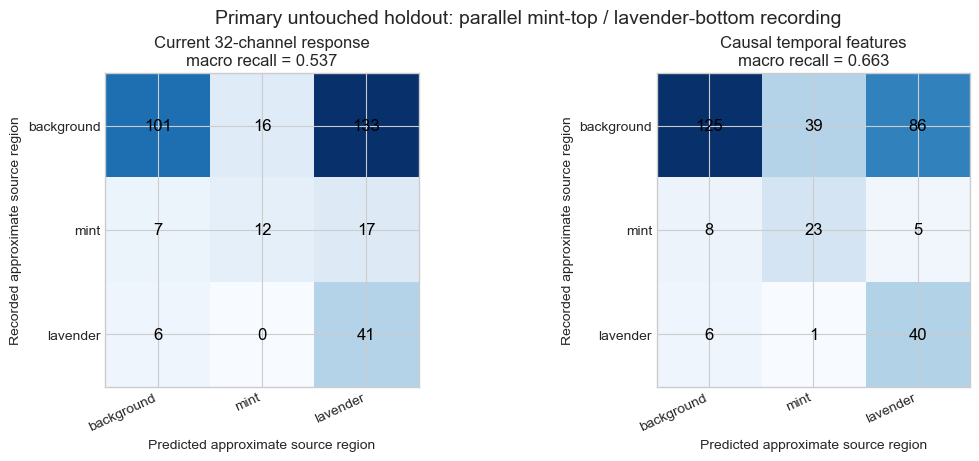

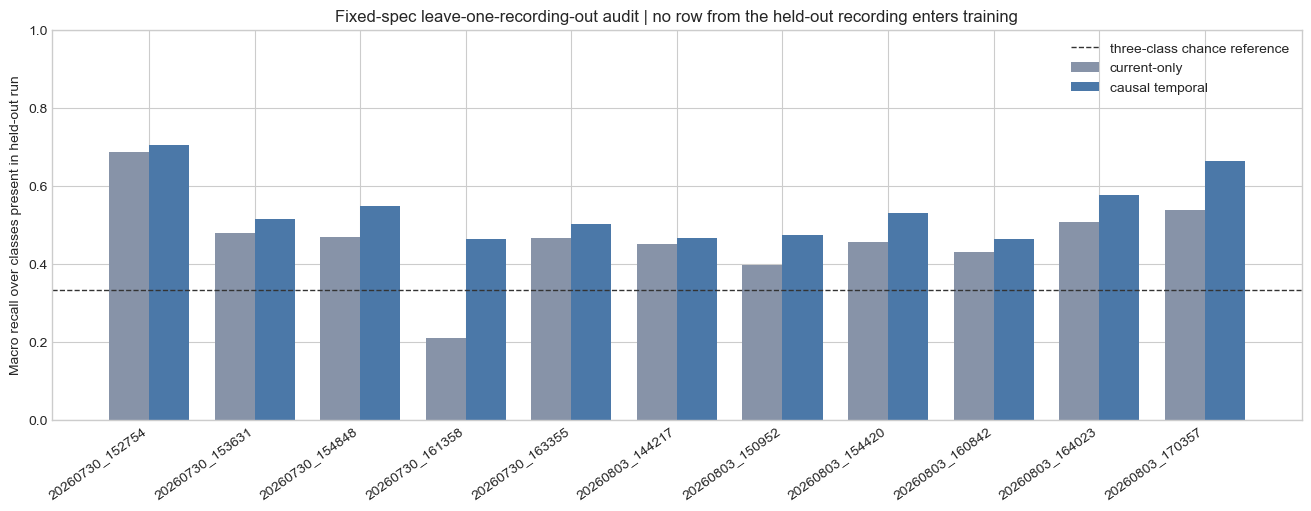

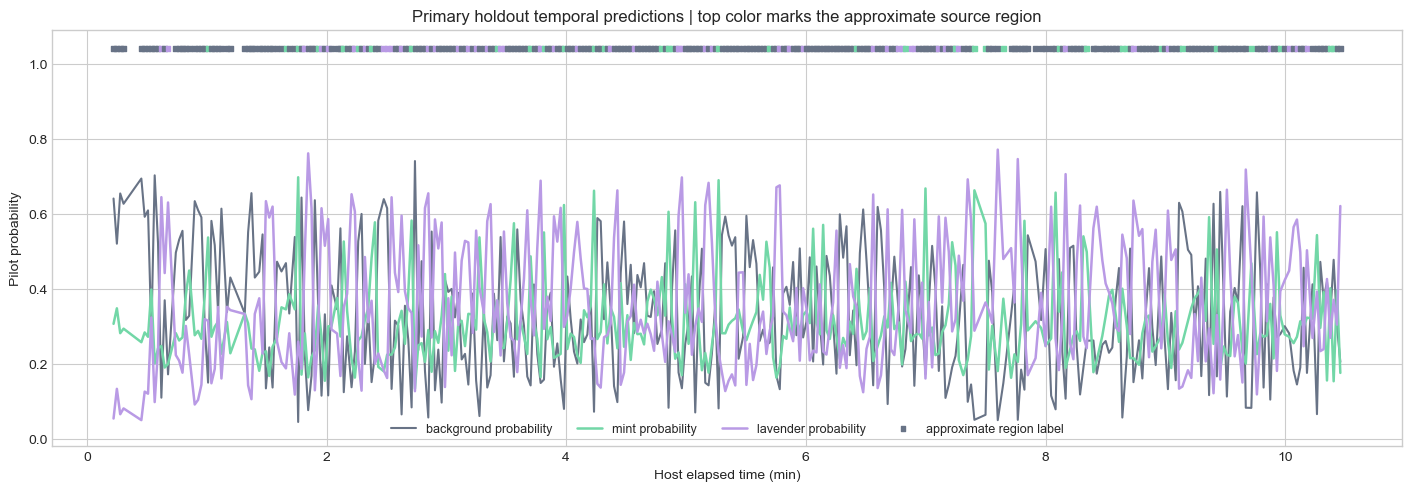

,holdout_session,model,test_rows_after_1_5s_thinning,classes_present,three_class_test,present_class_macro_recall,macro_f1,background_recall,mint_recall,lavender_recall
0,20260730_152754,current-only,192,"background,mint",False,0.685,0.739,0.935,0.436,0.000
1,20260730_152754,causal-temporal,192,"background,mint",False,0.704,0.769,0.922,0.487,0.000
2,20260730_153631,current-only,206,"background,mint,lavender",True,0.478,0.467,0.679,0.270,0.486
3,20260730_153631,causal-temporal,206,"background,mint,lavender",True,0.516,0.513,0.687,0.432,0.429
4,20260730_154848,current-only,199,"background,mint,lavender",True,0.469,0.449,0.640,0.318,0.447
5,20260730_154848,causal-temporal,199,"background,mint,lavender",True,0.548,0.507,0.647,0.364,0.632
6,20260730_161358,current-only,239,"background,lavender",False,0.210,0.324,0.325,0.000,0.095
7,20260730_161358,causal-temporal,239,"background,lavender",False,0.463,0.368,0.259,0.000,0.667
8,20260730_163355,current-only,317,"background,mint,lavender",True,0.466,0.479,0.839,0.190,0.370
9,20260730_163355,causal-temporal,317,"background,mint,lavender",True,0.502,0.499,0.780,0.207,0.519


In [5]:
MINT_COLOR = "#72d7a7"
LAVENDER_COLOR = "#b99ae5"
BACKGROUND_COLOR = "#687386"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, title, result in [
    (axes[0], "Current 32-channel response", primary_current),
    (axes[1], "Causal temporal features", primary_temporal),
]:
    matrix = result["confusion"]
    image = ax.imshow(matrix, cmap="Blues")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, str(matrix[row, column]), ha="center", va="center", color="black", fontsize=12)
    ax.set_xticks(range(3), CLASS_ORDER, rotation=25, ha="right")
    ax.set_yticks(range(3), CLASS_ORDER)
    ax.set_xlabel("Predicted approximate source region")
    ax.set_ylabel("Recorded approximate source region")
    ax.set_title(f"{title}\nmacro recall = {result['present_class_macro_recall']:.3f}")
fig.suptitle("Primary untouched holdout: parallel mint-top / lavender-bottom recording", fontsize=14)
plt.show()

pivot = loso.pivot(index="holdout_session", columns="model", values="present_class_macro_recall")
fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
x = np.arange(len(pivot))
width = 0.38
ax.bar(x - width / 2, pivot["current-only"], width, color="#8793a8", label="current-only")
ax.bar(x + width / 2, pivot["causal-temporal"], width, color="#4b78a8", label="causal temporal")
ax.axhline(1 / 3, color="#333333", linestyle="--", linewidth=1, label="three-class chance reference")
ax.set_xticks(x, pivot.index, rotation=35, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Macro recall over classes present in held-out run")
ax.set_title("Fixed-spec leave-one-recording-out audit | no row from the held-out recording enters training")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
minutes = predictions["host_elapsed_s"] / 60.0
ax.plot(minutes, predictions["probability_background"], color=BACKGROUND_COLOR, linewidth=1.5, label="background probability")
ax.plot(minutes, predictions["probability_mint"], color=MINT_COLOR, linewidth=1.8, label="mint probability")
ax.plot(minutes, predictions["probability_lavender"], color=LAVENDER_COLOR, linewidth=1.8, label="lavender probability")
truth_color = predictions["target_source_label"].map({
    "background": BACKGROUND_COLOR, "mint": MINT_COLOR, "lavender": LAVENDER_COLOR
})
ax.scatter(minutes, np.full(len(predictions), 1.04), c=truth_color, s=12, marker="s", clip_on=False, label="approximate region label")
ax.set_ylim(-0.02, 1.09)
ax.set_xlabel("Host elapsed time (min)")
ax.set_ylabel("Pilot probability")
ax.set_title("Primary holdout temporal predictions | top color marks the approximate source region")
ax.legend(ncol=4, fontsize=9, loc="lower center")
plt.show()

display(loso.round(3))


In [6]:
primary_gain = (
    primary_temporal["present_class_macro_recall"]
    - primary_current["present_class_macro_recall"]
)
mixed_temporal = mixed_loso[mixed_loso["model"] == "causal-temporal"]
mixed_current = mixed_loso[mixed_loso["model"] == "current-only"]

display(Markdown(
    f"""## Result and decision

The primary whole-recording holdout contains **{len(primary_test):,} conservatively thinned test rows** and all three approximate classes. The current-only model reaches macro recall **{primary_current["present_class_macro_recall"]:.3f}**; causal temporal context reaches **{primary_temporal["present_class_macro_recall"]:.3f}**, a gain of **{primary_gain:.3f}** without using any row from the held-out recording.

Across the nine leave-one-recording-out folds that contain background, mint, and lavender, the causal temporal model has median macro recall **{mixed_temporal["present_class_macro_recall"].median():.3f}**, versus **{mixed_current["present_class_macro_recall"].median():.3f}** for current-only input. Three-class chance is 0.333, so this is an encouraging pilot signal—but the fold-to-fold spread is substantial.

### What is frozen versus what is not

- **Frozen now:** cleaning rules, geometry assumptions, eligibility logic, raw lineage, causal feature definition, regularization, thinning interval, random seed, and primary holdout.
- **Not claimed as final:** the trained pilot classifier. It is saved for exact reproducibility, but it should not be called a validated or generalizable odor model.

### Why the small dataset still helps

The 11 runs are enough to test the pipeline, expose leakage, compare current versus temporal context, and prioritize new recordings. They are not enough to estimate performance across days, source preparations, rooms, or devices. The model must be evaluated by complete recording—as done here—because rows within one recording share sensor history, preparation, and environment.
"""
))

artifacts = pd.DataFrame({
    "artifact": [
        "frozen cleaning schema", "auditable processed table", "run manifest",
        "10-run pilot model", "primary holdout predictions",
        "primary holdout metrics", "leave-one-recording-out metrics"
    ],
    "path": [
        schema_path.relative_to(ROOT), table_path.relative_to(ROOT), manifest_path.relative_to(ROOT),
        model_path.relative_to(ROOT), predictions_path.relative_to(ROOT),
        metrics_path.relative_to(ROOT), loso_path.relative_to(ROOT)
    ],
})
display(artifacts)


## Result and decision

The primary whole-recording holdout contains **333 conservatively thinned test rows** and all three approximate classes. The current-only model reaches macro recall **0.537**; causal temporal context reaches **0.663**, a gain of **0.127** without using any row from the held-out recording.

Across the nine leave-one-recording-out folds that contain background, mint, and lavender, the causal temporal model has median macro recall **0.516**, versus **0.466** for current-only input. Three-class chance is 0.333, so this is an encouraging pilot signal—but the fold-to-fold spread is substantial.

### What is frozen versus what is not

- **Frozen now:** cleaning rules, geometry assumptions, eligibility logic, raw lineage, causal feature definition, regularization, thinning interval, random seed, and primary holdout.
- **Not claimed as final:** the trained pilot classifier. It is saved for exact reproducibility, but it should not be called a validated or generalizable odor model.

### Why the small dataset still helps

The 11 runs are enough to test the pipeline, expose leakage, compare current versus temporal context, and prioritize new recordings. They are not enough to estimate performance across days, source preparations, rooms, or devices. The model must be evaluated by complete recording—as done here—because rows within one recording share sensor history, preparation, and environment.


,artifact,path
0,frozen cleaning schema,experiments\long-sequence\processed\cleaning-v1\cleaning_schema_v1.json
1,auditable processed table,experiments\long-sequence\processed\cleaning-v1\long_sequence_processed_v1.csv.gz
2,run manifest,experiments\long-sequence\processed\cleaning-v1\run_manifest.csv
3,10-run pilot model,experiments\long-sequence\processed\cleaning-v1\sequence_source_classifier_pilot_v1.joblib
4,primary holdout predictions,experiments\long-sequence\processed\cleaning-v1\primary_holdout_predictions.csv
5,primary holdout metrics,experiments\long-sequence\processed\cleaning-v1\primary_holdout_metrics.json
6,leave-one-recording-out metrics,experiments\long-sequence\processed\cleaning-v1\leave_one_recording_out_metrics.csv
